# Moving Averages

* RSI - overbought if RSI is above 70 and oversold when under 30
* MACD - shows relationship between two moving averages of a security's price. MACD = 26-day EMA - 12-day EMA
* Bollinger Bands - Plotted two std. from a simple moving average. Help to identify whether an asset is overbought/oversold

Most used technical indicator is the 200 and 50-day moving average. Which we will explore below.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from utils.read_prices import read_parquet
from utils.metrics import Metrics as m
import talib

In [2]:
df = read_parquet()
df.head()

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
Date,,,,,,,,
2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900,0.20,NaN,NaN
2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600,0.20,0.997937,-0.002065
2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800,0.20,0.992093,-0.007938
2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500,0.36,1.007163,0.007137
2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600,0.36,0.997389,-0.002615


In [ ]:
#Using the cumulative returns we can simulate an investment of $5,000 at the beginning of 2021 and run it through to the end of 2025 to see our total return over that time-frame.

init_investment = 5000.0

cum_investment = np.exp(df['log_returns'].cumsum())*init_investment

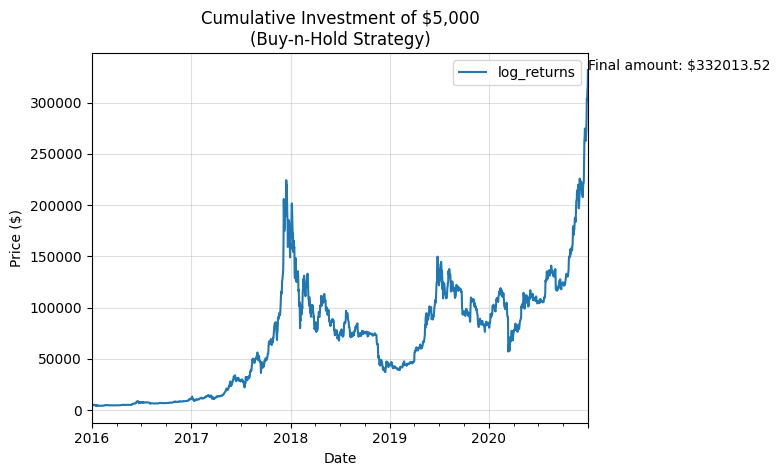

In [4]:
cum_investment.plot(kind='line')
plt.ylabel('Price ($)')
plt.legend()
plt.title('Cumulative Investment of $5,000\n(Buy-n-Hold Strategy)')

final_amount = round(cum_investment.tolist()[-1], 2)

plt.annotate(text=f"Final amount: ${final_amount}",
            xy=(cum_investment.index.tolist()[-1],
            cum_investment.tolist()[-1]))
plt.grid(alpha=.4)
plt.show()

In [5]:
'''
Terminal Return:

This approach ignores intermediate retuns and only considers the initial and terminal asset prices; a simplified view of the asset price's grouth.

Returns the decimal of the return.

In the example from above:
'''

terminal_return = round((final_amount / init_investment) - 1, 2)*100

print(f"Terminal return of an initial investment of $5,000: {terminal_return:.2f}%")
print(f"Terminal return of bitcoin during the same time-frame: {m.terminal_return(df['log_returns'])*100:.2f}%")

Terminal return of an initial investment of $5,000: 6540.00%
Terminal return of bitcoin during the same time-frame: 6540.27%


In [6]:
## checking to see that the terminal return as a mulitple checks out

(df['Close'].tolist()[0] * (1 + m.terminal_return(df['log_returns']))), df['Close'].tolist()[-1]

(28840.953124999876, 28840.953125)

In [7]:
'''
Annualizing Returns:

This metric compares different assets that might have different time-scales. Our bitcoin price has daily, but other assets might have monthly and this would be useful to use to compare the two investments.


'''
daily_returns = df['returns'].prod() ** (1 / df['returns'].shape[0]) - 1

'''
Let us decompose the sequence of operations here. First, we construct the 1+R returns for each day, then perform sequential compounding using the prod() function to obtain the cumulative terminal return in 1+R format. Before subtracting one, we raise it to the power of 1/N, where N is the number of rows in the DataFrame. This gives the geometric mean of the returns in 1+R format. We do not use the arithmetic mean here.
'''

annualized_returns_long_way = ((1 + daily_returns) ** 365) - 1

'''
We assume a fixed daily return as the geometric mean and roll it forward by a year, corresponding to 365 trading days. Again, convert between 1+R return and the normal return.
'''

## same calculation but in ont line
annualized_returns_short_way = df['returns'].prod()**(365 / df['returns'].shape[0]) - 1

print(annualized_returns_long_way)
print(annualized_returns_short_way)
print(m.annualized_return(df['log_returns']))

1.3133298991034934
1.3133298991034779
1.3133298991034779


In [8]:
'''
Volatility and Risk:

The standard deviation (measure of volatility) of the returns measures "how large the prices swing around the mean price and serves as a direct measure of the dispersion of returns." This metric plays an important role in assessing the risk tolerance in a portfolio.

Volatility can be daily, monthly, yearly, etc. Our case it is daily.

'''

price_stats = df.describe()
price_stats

,Close,High,Low,Open,Volume,interest_rate,returns,log_returns
count,1826.000000,1826.000000,1826.000000,1826.000000,1.826000e+03,1826.000000,1825.000000,1825.000000
mean,6118.848393,6259.301537,5945.559781,6103.383477,1.164336e+10,1.151857,1.003077,0.002299
std,4703.295017,4820.207635,4535.488914,4674.882347,1.376704e+10,0.807101,0.039170,0.039534
min,364.330994,374.950012,354.914001,365.072998,2.851400e+07,0.040000,0.628305,-0.464730
25%,1187.825043,1206.202515,1172.047485,1184.262512,3.338000e+08,0.380000,0.988796,-0.011267
50%,6413.792480,6534.830078,6314.354980,6412.694824,5.302091e+09,1.160000,1.002180,0.002178
75%,9208.396973,9360.110352,9035.487061,9209.826904,1.898423e+10,1.907500,1.017551,0.017399
max,28840.953125,28937.740234,27360.089844,27360.089844,7.415677e+10,2.450000,1.252472,0.225119


In [9]:
## price volatility

price_volatility = price_stats['returns'].loc['std']
print(price_volatility)
print(m.volatility(df['returns']))

0.039169565899702836
0.039169565899702836


In [10]:
'''
Annulaize Volatility:

Like the annualization of returns makes it easier for us to compare two assets with different time-frames, so to does annulaizing the volatility.

square root(T) * single period volatility 
     |                   |
  T = 365 since      our case this is daily
  our time-frame
    is daily

'''

annualized_volatility = np.sqrt(365) * price_volatility

print(annualized_volatility)
print(m.annualized_volatility(T=365, single_period_volatility=m.volatility(df['returns'])))

0.7483335057723091
0.7483335057723091


In [11]:
'''
Sharpe Ratio:

Divide the excess return by volatility to assess risk-adjusted performance.

Risk-free rate is typically the Treasury bill or bond.

Higher -> investment yields higher returns for the same level of risk compared to other investments or the overall market.

More accurate assessment of investment's performance relative to overall market conditions.

sharpe_ratio = average_return - risk_free_rate / annualized_volatility
'''

risk_free_rate = .03

excess_return = annualized_returns_short_way - risk_free_rate

sharpe_ratio = excess_return / annualized_volatility

print(sharpe_ratio)
print(m.sharpe_ratio(annualized_returns=annualized_returns_short_way,
                           annualized_volatility=annualized_volatility,
                           risk_free_rate=.03))

1.7149170646569298
1.7149170646569298


## Trend-Following Strategies

In [12]:
df = df[['Close', 'Volume', 'returns', 'log_returns', 'interest_rate']].copy().dropna()  ## copy for moving averages
df.head()

,Close,Volume,returns,log_returns,interest_rate
Date,,,,,
2016-01-02,433.437988,30096600,0.997937,-0.002065,0.20
2016-01-03,430.010986,39633800,0.992093,-0.007938,0.20
2016-01-04,433.091003,38477500,1.007163,0.007137,0.36
2016-01-05,431.959991,34522600,0.997389,-0.002615,0.36
2016-01-06,429.105011,34042500,0.993391,-0.006631,0.36


In [13]:
'''
Moving averages:

EMA's tend to react quicker to more recent price changes than SMA's, making them more preferable to short-term traders/more volatile markets

EMA's might work better for bitcoin market...

Moving averages can also help identify support and resistance levels. Support level is a price/range where the price has had trouble falling below over a certain period, whereas the resistance level is one where the price has had trouble breaking past.

When short-term moving average crosses above the long-term moving average, it signals a buy action (enter long position).

When the oposite happens it signals a sell action (enter short position).

**If only one trend line**, the strategy works the same. If the price is greater than the moving average this signals a buy action, and vice versa.
'''

window = 50

SMA1 = 'SMA-'+str(window)

df[SMA1] = df['Close'].rolling(window).mean()

## longer period SMA

window = 200

SMA2 = 'SMA-'+str(window)

df[SMA2] = df['Close'].rolling(window).mean()

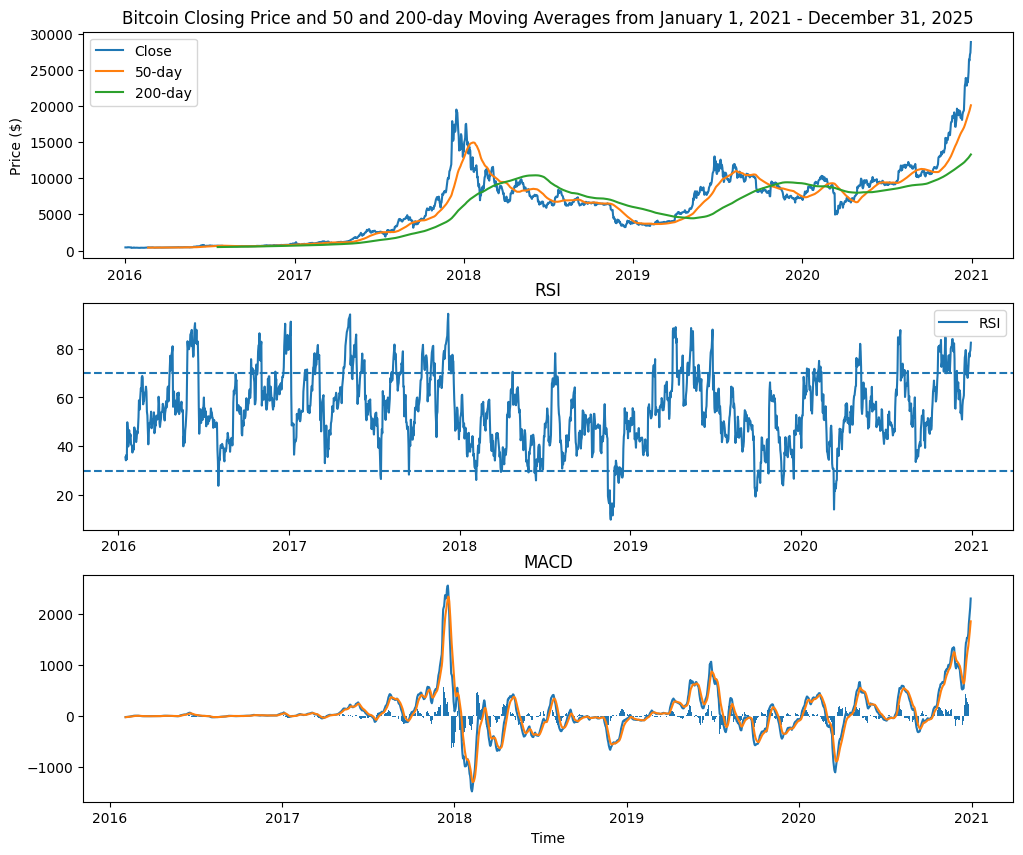

In [14]:
fig, ax = plt.subplots(3,1, figsize=(12,10))

rsi = talib.RSI(df['Close'])
macd = talib.MACD(df['Close'])

ax[0].plot(df[['Close', 'SMA-50', 'SMA-200']], label=['Close', '50-day', '200-day'])
ax[0].set_title('Bitcoin Closing Price and 50 and 200-day Moving Averages from January 1, 2021 - December 31, 2025')
ax[0].set_ylabel('Price ($)')
ax[0].legend()

ax[1].plot(rsi, label='RSI')
ax[1].set_title('RSI')
ax[1].axhline(70, linestyle='--')
ax[1].axhline(30, linestyle='--')
ax[1].legend()

ax[2].plot(macd[0])
ax[2].plot(macd[1])
ax[2].bar(df.index, macd[2])
ax[2].set_title('MACD')
# ax[2].legend()

plt.xlabel('Time')
plt.show()

In [15]:
## buy signal
df['signal'] = np.where(df['SMA-50'] > df['SMA-200'], 1, 0)

## sell signal
df['signal'] = np.where(df['SMA-50'] < df['SMA-200'], -1, df['signal'])

In [16]:
df['signal'].value_counts()

signal
 1    1063
-1     563
 0     199
Name: count, dtype: int64

In [17]:
df.dropna(inplace=True)

In [18]:
df['signal'].value_counts(), df['signal'].value_counts(normalize=True)

(signal
  1    1063
 -1     563
 Name: count, dtype: int64,
 signal
  1    0.653752
 -1    0.346248
 Name: proportion, dtype: float64)

In [19]:
'''
Trend-Following Strategy:

Multiplying the 'signal' column with the 'log_returns' column we obtain the single-period log return for the trend following strategy.
'''

df['log_return_trend_follow'] = df['signal'] * df['log_returns']

# Compared with the buy-and-hold strategy, the key difference is the additional shorting actions generated by the trend-following strategy. That is, when the stock price drops, the buy-and-hold strategy will register a loss, while the trend-following strategy will make a profit if the trading signal is to go short. Creating a good trading signal thus makes all the difference.

In [20]:
'''
Next, we create explicit trading actions. The signal column tells us whether we should go long or short in the given asset under the trend-following strategy. However, this does not mean we need to make a trade at every period. If the signal remains the same for two consecutive periods, we simply hold on to the position and remain seated. In other words, there is no trading action for this specific trading day. This applies in the case of two consecutive 1s or –1s in the signal column.
'''

df['action'] = df['signal'].diff()

In [21]:
df['action']

Date
2016-07-19    NaN
2016-07-20    0.0
2016-07-21    0.0
2016-07-22    0.0
2016-07-23    0.0
             ... 
2020-12-26    0.0
2020-12-27    0.0
2020-12-28    0.0
2020-12-29    0.0
2020-12-30    0.0
Name: action, Length: 1626, dtype: float64

In [22]:
df['action'].value_counts()

action
 0.0    1619
-2.0       3
 2.0       3
Name: count, dtype: int64

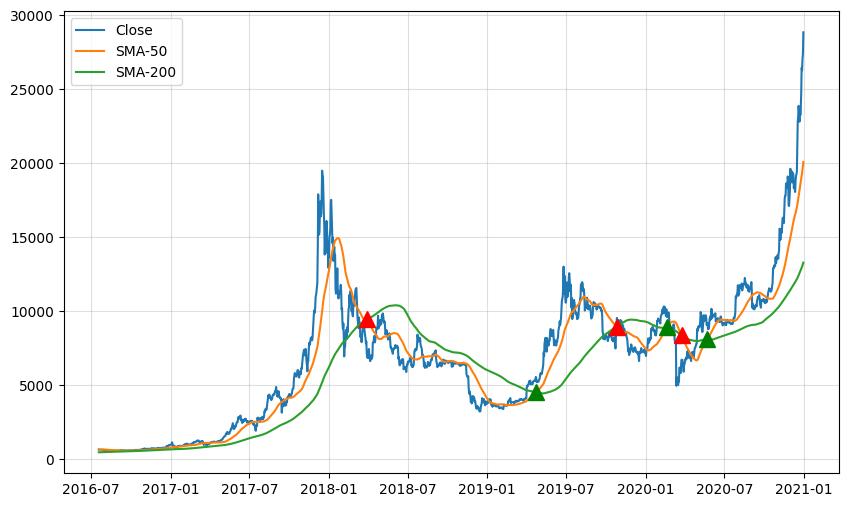

In [23]:
plt.figure(figsize=(10,6))

plt.plot(df['Close'], label='Close')
plt.plot(df['SMA-50'], label='SMA-50')
plt.plot(df['SMA-200'], label='SMA-200')
plt.plot(
    df.loc[df.action == 2].index,
    df['SMA-50'][df.action == 2],
    '^',
    color = 'g',
    markersize = 12)
plt.plot(
    df.loc[df.action == -2].index,
    df['SMA-200'][df.action == -2],
    '^',
    color = 'r',
    markersize = 12)

plt.grid(alpha=.4)
plt.legend()
plt.show()

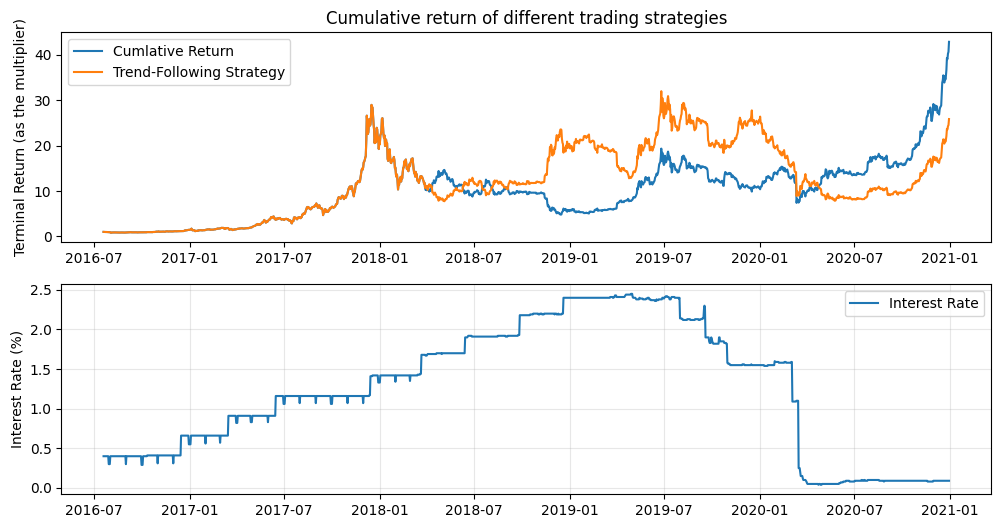

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))

ax[0].plot(np.exp(df[['log_returns', 'log_return_trend_follow']].cumsum()),
           label=['Cumlative Return', 'Trend-Following Strategy'])
ax[0].set_title('Cumulative return of different trading strategies')
ax[0].set_ylabel('Terminal Return (as the multiplier)')
ax[0].legend()

ax[1].plot(df['interest_rate'], label='Interest Rate')
ax[1].set_ylabel('Interest Rate (%)')
ax[1].legend()

plt.grid(alpha=.3)
plt.show()

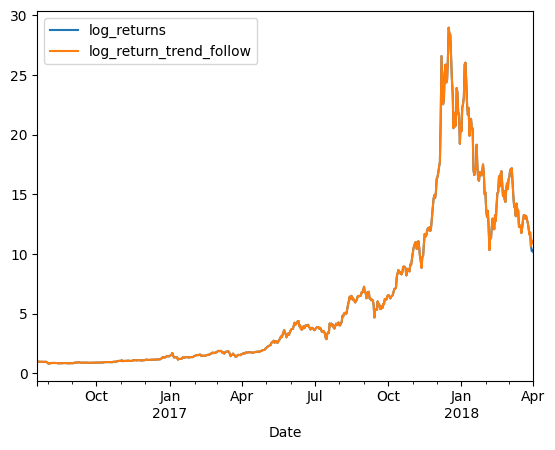

In [25]:
np.exp(df[['log_returns', 'log_return_trend_follow']].loc['2016-07-01':'2018-04-01'].cumsum()).plot(kind='line')
plt.show()

In [26]:
## terminal returns buy-n-hold
terminal_return_buy_n_hold = m.terminal_return(df['log_returns']) * 100

## terminal return trend-follow
terminal_return_trend_follow = m.terminal_return(df['log_return_trend_follow']) * 100

print(f"Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: {terminal_return_buy_n_hold:.2f}%\n")
print(f"Terminal return of trend-follow strategy from July 2016 to Decmeber 2020: {terminal_return_trend_follow:.2f}%")

Terminal return of buy-n-hold strategy from July 2016 to Decmeber 2020: 4184.76%

Terminal return of trend-follow strategy from July 2016 to Decmeber 2020: 2484.21%


Looking at the terminal returns we can see that the buy-n-hold strategy gives a slight better return, but like I mentioned before, the price swing from the beggining of this period to the end saw bitcoin go from around the $20,000 mark to over $100,000, indicating that the strategies might not be indicitive of other periods where the price is on a different trajectory.

In [27]:
# df.to_parquet('../price_ranges/btc_price_2016-2020.parquet')

### Backtest

In [28]:
from utils.backtest import MovingAverageBackTest

In [29]:
mabt = MovingAverageBackTest('BTC-USD', '2021-01-01', '2025-12-31', trans_cost=0.0, amount=5000)
cret, cstrat = mabt.strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(14347.23), np.float64(5446.26))

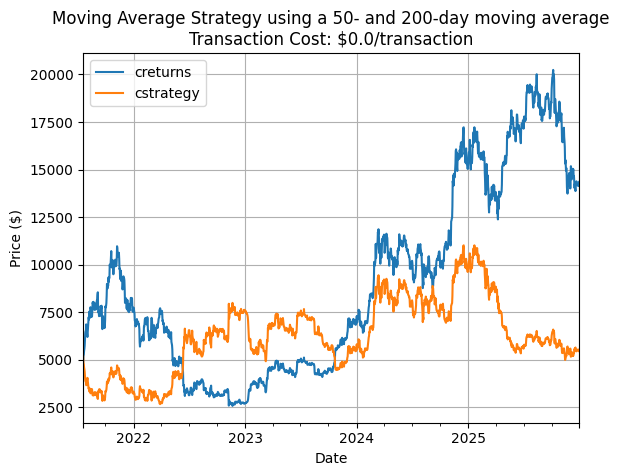

In [30]:
mabt.plot_strategy()

In [31]:
mabt.get_terminal_return()

(1.87, 0.09)

In [32]:
mabt.get_annualized_return()

(np.float64(0.27), np.float64(0.02))

In [ ]:
mabt_hourly = MovingAverageBackTest('BTC-USD',
'2025-01-01',
'2025-12-31',
interval='4h',
trans_cost=0.0,
amount=5000)

cret, cstrat = mabt_hourly.strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(4634.0), np.float64(5791.91))

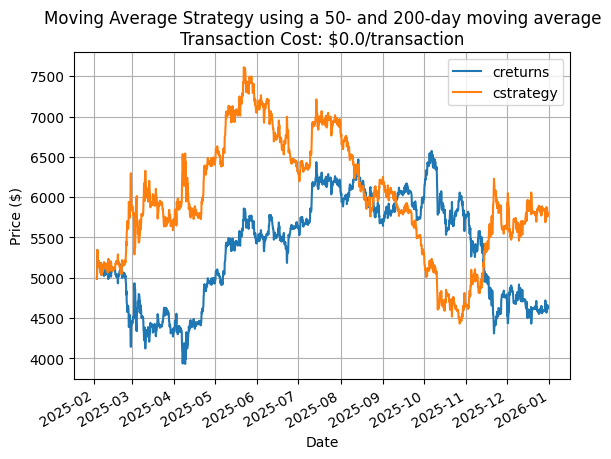

In [38]:
mabt_hourly.plot_strategy()

In [ ]:
mabt_hourly = MovingAverageBackTest('BTC-USD',
'2025-01-01',
'2025-12-31',
interval='4h',
trans_cost=0.36,
amount=5000)

cret, cstrat = mabt_hourly.strategy(sma1=50, sma2=200)
cret, cstrat

[*********************100%***********************]  1 of 1 completed


(np.float64(4634.0), np.float64(5785.66))

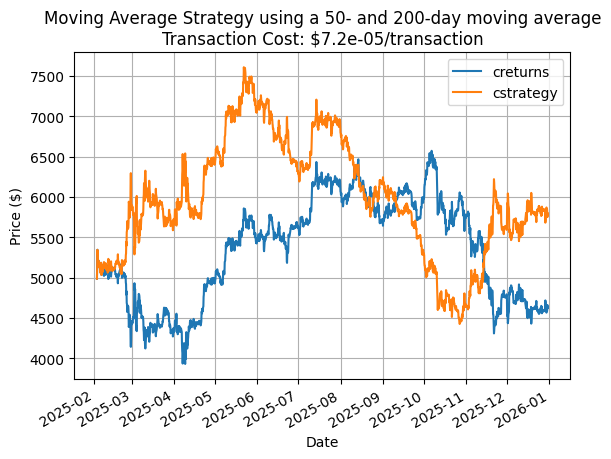

In [40]:
mabt_hourly.plot_strategy()